In [1]:
import pandas as pd

In [ ]:
df_train = pd.read_csv('mind/train/behaviors.tsv', sep='\t', header=None, names=['Impression ID', 'User ID','Time','History','Impressions'])
df_valid = pd.read_csv('mind/valid/behaviors.tsv', sep='\t', header=None, names=['Impression ID', 'User ID','Time','History','Impressions'])

In [3]:
df_train.head(5)

,Impression ID,User ID,Time,History,Impressions
0,1,U87243,11/10/2019 11:30:54 AM,N8668 N39081 N65259 N79529 N73408 N43615 N2937...,N78206-0 N26368-0 N7578-0 N58592-0 N19858-0 N5...
1,2,U598644,11/12/2019 1:45:29 PM,N56056 N8726 N70353 N67998 N83823 N111108 N107...,N47996-0 N82719-0 N117066-0 N8491-0 N123784-0 ...
2,3,U532401,11/13/2019 11:23:03 AM,N128643 N87446 N122948 N9375 N82348 N129412 N5...,N103852-0 N53474-0 N127836-0 N47925-1
3,4,U593596,11/12/2019 12:24:09 PM,N31043 N39592 N4104 N8223 N114581 N92747 N1207...,N38902-0 N76434-0 N71593-0 N100073-0 N108736-0...
4,5,U239687,11/14/2019 8:03:01 PM,N65250 N122359 N71723 N53796 N41663 N41484 N11...,N76209-0 N48841-0 N67937-0 N62235-0 N6307-0 N3...


In [ ]:

# Get unique user IDs from both datasets
train_users = set(df_train['User ID'])
valid_users = set(df_valid['User ID'])

# Find common users
common_users = train_users.intersection(valid_users)

# Filter both dataframes to keep only common users
df_train_filtered = df_train[df_train['User ID'].isin(common_users)]
df_valid_filtered = df_valid[df_valid['User ID'].isin(common_users)]

# Print info about before and after filtering
print(f"Before filtering - Train: {len(df_train)} rows, Valid: {len(df_valid)} rows")
print(f"Common users: {len(common_users)}")
print(f"After filtering - Train: {len(df_train_filtered)} rows, Valid: {len(df_valid_filtered)} rows")

Before filtering - Train: 2232748 rows, Valid: 376471 rows
Common users: 216778
After filtering - Train: 947193 rows, Valid: 327861 rows


In [5]:
def process_history(df):
    # Create a copy to avoid modifying the original dataframe
    df_copy = df.copy()
    
    # Function to split history string into a list
    def split_history(history):
        if pd.isna(history) or history == '':
            return []
        return history.split()
    
    # Apply the function to the History column
    df_copy['History_List'] = df_copy['History'].apply(split_history)
    
    return df_copy

# Process both train and validation dataframes
df_train_processed = process_history(df_train_filtered)
df_valid_processed = process_history(df_valid_filtered)


# Show examples of the new columns
print("\nExample of processed history for train data:")
print(df_train_processed[['User ID', 'History_List']].head(3))


Example of processed history for train data:
   User ID                                       History_List
1  U598644  [N56056, N8726, N70353, N67998, N83823, N11110...
3  U593596  [N31043, N39592, N4104, N8223, N114581, N92747...
4  U239687  [N65250, N122359, N71723, N53796, N41663, N414...


In [6]:
# Analyze user statistics in the filtered training data
user_counts = df_train_processed['User ID'].value_counts()

# Get basic statistics
total_users = len(user_counts)
total_users

216778

In [ ]:
df_train_news = pd.read_csv('mind/train/news.tsv', sep='\t', header=None, names=['News ID', 'Category', 'Subcategory', 'Title', 'Abstract', 'URL','Tutke Entities','Abstract Entities'])
df_valid_news = pd.read_csv('mind/valid/news.tsv', sep='\t', header=None, names=['News ID', 'Category', 'Subcategory', 'Title', 'Abstract', 'URL','Tutke Entities','Abstract Entities'])

In [8]:
# Combine news dataframes from train and valid sets
combined_news_df = pd.concat([df_train_news, df_valid_news])

# Drop duplicate news IDs (keep the first occurrence)
combined_news_df = combined_news_df.drop_duplicates(subset='News ID', keep='first')

# Check the shape of the combined dataframe
print(f"Combined news dataframe shape: {combined_news_df.shape}")
print(f"Total unique news items: {combined_news_df.shape[0]}")
print(f"Original train news items: {df_train_news.shape[0]}")
print(f"Original valid news items: {df_valid_news.shape[0]}")
print(f"Overlap count: {df_train_news.shape[0] + df_valid_news.shape[0] - combined_news_df.shape[0]}")

# Verify overlap percentage
overlap_percent = (df_train_news.shape[0] + df_valid_news.shape[0] - combined_news_df.shape[0]) / combined_news_df.shape[0] * 100
print(f"Overlap percentage: {overlap_percent:.2f}%")

# Show a few rows from the combined dataframe
combined_news_df.head()

Combined news dataframe shape: (104151, 8)
Total unique news items: 104151
Original train news items: 101527
Original valid news items: 72023
Overlap count: 69399
Overlap percentage: 66.63%


,News ID,Category,Subcategory,Title,Abstract,URL,Tutke Entities,Abstract Entities
0,N88753,lifestyle,lifestyleroyals,"The Brands Queen Elizabeth, Prince Charles, an...","Shop the notebooks, jackets, and more that the...",https://assets.msn.com/labs/mind/AAGH0ET.html,"[{""Label"": ""Prince Philip, Duke of Edinburgh"",...",[]
1,N45436,news,newsscienceandtechnology,Walmart Slashes Prices on Last-Generation iPads,Apple's new iPad releases bring big deals on l...,https://assets.msn.com/labs/mind/AABmf2I.html,"[{""Label"": ""IPad"", ""Type"": ""J"", ""WikidataId"": ...","[{""Label"": ""IPad"", ""Type"": ""J"", ""WikidataId"": ..."
2,N23144,health,weightloss,50 Worst Habits For Belly Fat,These seemingly harmless habits are holding yo...,https://assets.msn.com/labs/mind/AAB19MK.html,"[{""Label"": ""Adipose tissue"", ""Type"": ""C"", ""Wik...","[{""Label"": ""Adipose tissue"", ""Type"": ""C"", ""Wik..."
3,N86255,health,medical,Dispose of unwanted prescription drugs during ...,NaN,https://assets.msn.com/labs/mind/AAISxPN.html,"[{""Label"": ""Drug Enforcement Administration"", ...",[]
4,N93187,news,newsworld,The Cost of Trump's Aid Freeze in the Trenches...,Lt. Ivan Molchanets peeked over a parapet of s...,https://assets.msn.com/labs/mind/AAJgNsz.html,[],"[{""Label"": ""Ukraine"", ""Type"": ""G"", ""WikidataId..."


In [9]:
import random

# Create a dictionary mapping from News ID to Title
news_id_to_title = dict(zip(combined_news_df['News ID'], combined_news_df['Title']))

# Check the size of the dictionary
print(f"Total news IDs in mapping: {len(news_id_to_title)}")

# Display a few examples
sample_news_ids = random.sample(list(news_id_to_title.keys()), 5)
for news_id in sample_news_ids:
    print(f"{news_id}: {news_id_to_title[news_id][:50]}...")

Total news IDs in mapping: 104151
N12564: Why Minkah Fitzpatrick has been the key to fixing ...
N63844: Emily Mayfield tries Cleveland's coolest Pilates-i...
N105959: Joe Alwyn on Buzz Around Taylor Swift Romance: 'I'...
N10671: Convicted Ex-Arkansas Senator Released From Prison...
N3435: Florida woman allegedly flees 2 car crashes, kills...


In [10]:
# Function to convert history news IDs to titles using the dictionary
def get_news_titles(news_ids, news_id_to_title_dict):
    """Convert a list of news IDs to their corresponding titles using dictionary lookup"""
    titles = []
    for news_id in news_ids:
        # Get the title from the dictionary
        if news_id in news_id_to_title_dict:
            titles.append(news_id_to_title_dict[news_id])
    return titles

# Function to process a dataframe by converting IDs to titles
def add_title_information(df, news_id_to_title_dict):
    """Add title information to the dataframe based on news IDs"""
    df_copy = df.copy()
    
    # Convert history list to a list of titles
    df_copy['History_Title_List'] = df_copy['History_List'].apply(
        lambda x: get_news_titles(x, news_id_to_title_dict) if isinstance(x, list) else []
    )
    
    return df_copy

# Process both train and validation dataframes using the existing dictionary
df_train_with_titles = add_title_information(df_train_processed, news_id_to_title)
df_valid_with_titles = add_title_information(df_valid_processed, news_id_to_title)


In [11]:
def process_impressions(df):
    # Create a copy of the dataframe
    df_copy = df.copy()
    
    # Function to split impressions string into a list of (news_id, label) tuples
    def split_impressions(impressions):
        if pd.isna(impressions) or impressions == '':
            return []
        
        impression_list = impressions.split()
        result = []
        for imp in impression_list:
            parts = imp.split('-')
            if len(parts) == 2:
                result.append((parts[0], int(parts[1])))
        return result
    
    # Apply the function to the Impressions column
    df_copy['Impressions_List'] = df_copy['Impressions'].apply(split_impressions)
    
    # Explode the dataframe to create one row per impression
    df_exploded = df_copy.explode('Impressions_List')
    
    # Extract news_id and label from the tuples
    df_exploded['News_ID'] = df_exploded['Impressions_List'].apply(lambda x: x[0] if x else None)
    df_exploded['Label'] = df_exploded['Impressions_List'].apply(lambda x: x[1] if x else None)
    
    # Drop the intermediate column
    df_exploded = df_exploded.drop('Impressions_List', axis=1)
    df_exploded = df_exploded.drop('Impressions', axis=1)
    df_exploded = df_exploded.drop('History', axis=1)
    
    return df_exploded

# Process both train and validation dataframes
df_train_exploded = process_impressions(df_train_with_titles)
df_valid_exploded = process_impressions(df_valid_with_titles)

# Show examples of the new format
print("\nExample of processed impressions for train data:")
print(df_train_exploded.head(10))
print(f"\nTrain data shape after exploding: {df_train_exploded.shape}")
print(f"Valid data shape after exploding: {df_valid_exploded.shape}")



Example of processed impressions for train data:
   Impression ID  User ID                   Time  \
1              2  U598644  11/12/2019 1:45:29 PM   
1              2  U598644  11/12/2019 1:45:29 PM   
1              2  U598644  11/12/2019 1:45:29 PM   
1              2  U598644  11/12/2019 1:45:29 PM   
1              2  U598644  11/12/2019 1:45:29 PM   
1              2  U598644  11/12/2019 1:45:29 PM   
1              2  U598644  11/12/2019 1:45:29 PM   
1              2  U598644  11/12/2019 1:45:29 PM   
1              2  U598644  11/12/2019 1:45:29 PM   
1              2  U598644  11/12/2019 1:45:29 PM   

                                        History_List  \
1  [N56056, N8726, N70353, N67998, N83823, N11110...   
1  [N56056, N8726, N70353, N67998, N83823, N11110...   
1  [N56056, N8726, N70353, N67998, N83823, N11110...   
1  [N56056, N8726, N70353, N67998, N83823, N11110...   
1  [N56056, N8726, N70353, N67998, N83823, N11110...   
1  [N56056, N8726, N70353, N67998, N83823

In [12]:
df_train_exploded

,Impression ID,User ID,Time,History_List,History_Title_List,News_ID,Label
1,2,U598644,11/12/2019 1:45:29 PM,"[N56056, N8726, N70353, N67998, N83823, N11110...",[Southwest Airlines flight diverted: Man assau...,N47996,0
1,2,U598644,11/12/2019 1:45:29 PM,"[N56056, N8726, N70353, N67998, N83823, N11110...",[Southwest Airlines flight diverted: Man assau...,N82719,0
1,2,U598644,11/12/2019 1:45:29 PM,"[N56056, N8726, N70353, N67998, N83823, N11110...",[Southwest Airlines flight diverted: Man assau...,N117066,0
1,2,U598644,11/12/2019 1:45:29 PM,"[N56056, N8726, N70353, N67998, N83823, N11110...",[Southwest Airlines flight diverted: Man assau...,N8491,0
1,2,U598644,11/12/2019 1:45:29 PM,"[N56056, N8726, N70353, N67998, N83823, N11110...",[Southwest Airlines flight diverted: Man assau...,N123784,0
...,...,...,...,...,...,...,...
2232746,2232747,U330725,11/12/2019 1:22:57 PM,"[N121944, N91510, N42280, N60061, N63032, N125...",[White House accidentally sends Ukraine talkin...,N100539,0
2232746,2232747,U330725,11/12/2019 1:22:57 PM,"[N121944, N91510, N42280, N60061, N63032, N125...",[White House accidentally sends Ukraine talkin...,N123151,0
2232746,2232747,U330725,11/12/2019 1:22:57 PM,"[N121944, N91510, N42280, N60061, N63032, N125...",[White House accidentally sends Ukraine talkin...,N79082,0
2232746,2232747,U330725,11/12/2019 1:22:57 PM,"[N121944, N91510, N42280, N60061, N63032, N125...",[White House accidentally sends Ukraine talkin...,N54239,0


In [13]:
# Function to process a dataframe by converting IDs to titles
def add_title_information(df, news_id_to_title_dict):
    """Add title information to the dataframe based on news IDs"""
    df_copy = df.copy()
    
    # Get the title for the current news item directly from dictionary
    df_copy['News_Title'] = df_copy['News_ID'].apply(
        lambda x: news_id_to_title_dict.get(x, None)
    )
    
    return df_copy

# Process both train and validation dataframes using the existing dictionary
df_train_ex_with_titles = add_title_information(df_train_exploded, news_id_to_title)
df_valid_ex_with_titles = add_title_information(df_valid_exploded, news_id_to_title)


In [14]:
df_train_ex_with_titles

,Impression ID,User ID,Time,History_List,History_Title_List,News_ID,Label,News_Title
1,2,U598644,11/12/2019 1:45:29 PM,"[N56056, N8726, N70353, N67998, N83823, N11110...",[Southwest Airlines flight diverted: Man assau...,N47996,0,Oprah's list of favorite things is full of gre...
1,2,U598644,11/12/2019 1:45:29 PM,"[N56056, N8726, N70353, N67998, N83823, N11110...",[Southwest Airlines flight diverted: Man assau...,N82719,0,Widow Sues Truth Aquatics Owner In Conception ...
1,2,U598644,11/12/2019 1:45:29 PM,"[N56056, N8726, N70353, N67998, N83823, N11110...",[Southwest Airlines flight diverted: Man assau...,N117066,0,How Big Is Your Turkey? Most Americans Pick Th...
1,2,U598644,11/12/2019 1:45:29 PM,"[N56056, N8726, N70353, N67998, N83823, N11110...",[Southwest Airlines flight diverted: Man assau...,N8491,0,'It's the biggest gift I've ever gotten:' Iraq...
1,2,U598644,11/12/2019 1:45:29 PM,"[N56056, N8726, N70353, N67998, N83823, N11110...",[Southwest Airlines flight diverted: Man assau...,N123784,0,Is the Alabama Football Dynasty Ending?
...,...,...,...,...,...,...,...,...
2232746,2232747,U330725,11/12/2019 1:22:57 PM,"[N121944, N91510, N42280, N60061, N63032, N125...",[White House accidentally sends Ukraine talkin...,N100539,0,The Latest Weight Loss Pills That Work And the...
2232746,2232747,U330725,11/12/2019 1:22:57 PM,"[N121944, N91510, N42280, N60061, N63032, N125...",[White House accidentally sends Ukraine talkin...,N123151,0,"UN urges Lebanon to build gov't of ""competence..."
2232746,2232747,U330725,11/12/2019 1:22:57 PM,"[N121944, N91510, N42280, N60061, N63032, N125...",[White House accidentally sends Ukraine talkin...,N79082,0,Ex-Astros say team electronically stole signs ...
2232746,2232747,U330725,11/12/2019 1:22:57 PM,"[N121944, N91510, N42280, N60061, N63032, N125...",[White House accidentally sends Ukraine talkin...,N54239,0,America's Most and Least Popular Senators


In [15]:
# Drop specified columns and reset index
df_cleaned_train = df_train_ex_with_titles.drop(['Impression ID', 'Time', 'History_List', 'News_ID'], axis=1)
# Reset the index to have a clean sequential index
df_cleaned_train = df_cleaned_train.reset_index(drop=True)
df_cleaned_valid = df_valid_ex_with_titles.drop(['Impression ID', 'Time', 'History_List', 'News_ID'], axis=1)
# Reset the index to have a clean sequential index
df_cleaned_valid = df_cleaned_valid.reset_index(drop=True)

In [ ]:
# Identify users with history length >= 7 in train or valid dataset
train_users_with_history = df_train_with_titles[df_train_with_titles['history_list_length'] >= 7]['User ID'].unique()
valid_users_with_history = df_valid_with_titles[df_valid_with_titles['History_List'].apply(lambda x: len(x) >= 7)]['User ID'].unique()

# Convert to sets for faster operations
train_users_with_history_set = set(train_users_with_history)
valid_users_with_history_set = set(valid_users_with_history)

# Find users with sufficient history in both datasets
users_with_sufficient_history = train_users_with_history_set.intersection(valid_users_with_history_set)

print(f"Users with sufficient history in train: {len(train_users_with_history_set)}")
print(f"Users with sufficient history in valid: {len(valid_users_with_history_set)}")
print(f"Users with sufficient history in both: {len(users_with_sufficient_history)}")

# Filter both datasets to keep only users with sufficient history
df_train_complete = df_cleaned_train[df_cleaned_train['User ID'].isin(users_with_sufficient_history)]
df_valid_complete = df_cleaned_valid[df_cleaned_valid['User ID'].isin(users_with_sufficient_history)]

# Reset the index
df_train_complete = df_train_complete.reset_index(drop=True)
df_valid_complete = df_valid_complete.reset_index(drop=True)

# Show the shapes before and after filtering
print(f"\nBefore filtering - Train: {len(df_cleaned_train)} rows, Valid: {len(df_cleaned_valid)} rows")
print(f"After filtering - Train: {len(df_train_complete)} rows, Valid: {len(df_valid_complete)} rows")

# Calculate percentage of data retained
train_retention = len(df_train_complete) / len(df_cleaned_train) * 100
valid_retention = len(df_valid_complete) / len(df_cleaned_valid) * 100

print(f"\nPercentage of train data retained: {train_retention:.2f}%")
print(f"Percentage of valid data retained: {valid_retention:.2f}%")

Users with sufficient history in train: 171398
Users with sufficient history in valid: 171398
Users with sufficient history in both: 171398

Before filtering - Train: 36618998 rows, Valid: 12366248 rows
After filtering - Train: 32907898 rows, Valid: 10483344 rows

Percentage of train data retained: 89.87%
Percentage of valid data retained: 84.77%


In [19]:
# Count interactions per user, separated by label
user_interaction_counts = df_train_complete.groupby('User ID')['Label'].count()
user_positive_counts = df_train_complete[df_train_complete['Label'] == 1].groupby('User ID')['Label'].count()
user_negative_counts = df_train_complete[df_train_complete['Label'] == 0].groupby('User ID')['Label'].count()

# Convert to DataFrame for easier analysis
interaction_stats = pd.DataFrame({
    'Total_Interactions': user_interaction_counts,
    'Positive_Interactions': user_positive_counts,
    'Negative_Interactions': user_negative_counts
})

# Fill NaN values with 0 (users who don't have any positive/negative interactions)
interaction_stats = interaction_stats.fillna(0).astype(int)

# Calculate positive interaction ratio
interaction_stats['Positive_Ratio'] = interaction_stats['Positive_Interactions'] / interaction_stats['Total_Interactions']

# Summary statistics
total_stats = interaction_stats.describe()

# Display summary statistics
print("Summary statistics for user interactions:")
print(total_stats)

# Count users with different interaction ranges
interaction_ranges = [(0, 10), (11, 30), (31, 50), (51, 100), (101, float('inf'))]
range_counts = {}

for low, high in interaction_ranges:
    if high == float('inf'):
        count = (interaction_stats['Total_Interactions'] > low).sum()
        range_counts[f">{low}"] = count
    else:
        count = ((interaction_stats['Total_Interactions'] >= low) & 
                 (interaction_stats['Total_Interactions'] <= high)).sum()
        range_counts[f"{low}-{high}"] = count

print("\nUser count by total interaction range:")
for range_label, count in range_counts.items():
    print(f"{range_label}: {count} users ({count/len(interaction_stats)*100:.2f}%)")

# Count users with at least N positive interactions
positive_thresholds = [1, 5, 10, 20, 30]
for threshold in positive_thresholds:
    count = (interaction_stats['Positive_Interactions'] >= threshold).sum()
    percent = count / len(interaction_stats) * 100
    print(f"\nUsers with at least {threshold} positive interactions: {count} ({percent:.2f}%)")

Summary statistics for user interactions:
       Total_Interactions  Positive_Interactions  Negative_Interactions  \
count       171398.000000          171398.000000          171398.000000   
mean           191.996978               7.970618             184.026360   
std            199.630127               8.521110             193.033296   
min              2.000000               1.000000               1.000000   
25%             54.000000               3.000000              50.000000   
50%            131.000000               5.000000             125.000000   
75%            262.000000              10.000000             252.000000   
max           2817.000000             192.000000            2718.000000   

       Positive_Ratio  
count   171398.000000  
mean         0.066318  
std          0.073868  
min          0.003344  
25%          0.029268  
50%          0.045455  
75%          0.072464  
max          0.750000  

User count by total interaction range:
0-10: 9317 users (5.44%)
1

In [ ]:
# Filter users with at least 4 positive interactions and at least 20 total interactions
min_positive_interactions = 4
min_total_interactions = 20

# Get users meeting the criteria
qualified_users = interaction_stats[
    (interaction_stats['Positive_Interactions'] >= min_positive_interactions) & 
    (interaction_stats['Total_Interactions'] >= min_total_interactions)
].index

print(f"Total users: {len(interaction_stats)}")
print(f"Users with at least {min_positive_interactions} positive interactions and {min_total_interactions} total interactions: {len(qualified_users)}")
print(f"Percentage of users retained: {len(qualified_users) / len(interaction_stats) * 100:.2f}%")

# Filter datasets to keep only qualified users
df_train_sampled = df_train_complete[df_train_complete['User ID'].isin(qualified_users)]
df_valid_sampled = df_valid_complete[df_valid_complete['User ID'].isin(qualified_users)]

# Reset the indices
df_train_sampled = df_train_sampled.reset_index(drop=True)
df_valid_sampled = df_valid_sampled.reset_index(drop=True)

# Show the shapes before and after filtering
print(f"\nBefore filtering - Train: {len(df_train_complete)} rows, Valid: {len(df_valid_complete)} rows")
print(f"After filtering - Train: {len(df_train_sampled)} rows, Valid: {len(df_valid_sampled)} rows")

# Calculate percentage of data retained
train_retention = len(df_train_sampled) / len(df_train_complete) * 100
valid_retention = len(df_valid_sampled) / len(df_valid_complete) * 100

print(f"\nPercentage of train data retained: {train_retention:.2f}%")
print(f"Percentage of valid data retained: {valid_retention:.2f}%")

Total users: 171398
Users with at least 4 positive interactions and 20 total interactions: 111780
Percentage of users retained: 65.22%

Before filtering - Train: 32907898 rows, Valid: 10483344 rows
After filtering - Train: 29462684 rows, Valid: 7667122 rows

Percentage of train data retained: 89.53%
Percentage of valid data retained: 73.14%


In [32]:
import random
import pandas as pd

# Set random seed for reproducibility
random.seed(42)

def sample_user_interactions(df, max_interactions=60, positive_cap_ratio=0.5):
    """
    Sample user interactions to a maximum number, prioritizing positive interactions.
    
    Args:
        df: DataFrame containing user interactions
        max_interactions: Maximum number of interactions to keep per user
        positive_cap_ratio: Maximum ratio of positive interactions (to avoid bias)
    
    Returns:
        DataFrame with sampled interactions
    """
    # Group by user
    user_groups = df.groupby('User ID')
    
    # Initialize an empty list to store sampled dataframes
    sampled_dfs = []
    
    for user_id, user_df in user_groups:
        # If user has fewer interactions than max, keep all
        if len(user_df) <= max_interactions:
            sampled_dfs.append(user_df)
            continue
        
        # Split into positive and negative interactions
        positive_df = user_df[user_df['Label'] == 1]
        negative_df = user_df[user_df['Label'] == 0]
        
        n_positive = len(positive_df)
        n_negative = len(negative_df)
        
        # Calculate how many to keep of each type
        # Priority: keep all positives unless they exceed the cap
        max_positive_to_keep = int(max_interactions * positive_cap_ratio)
        positive_to_keep = min(n_positive, max_positive_to_keep)
        
        # The rest are negative
        negative_to_keep = max_interactions - positive_to_keep
        
        # Sample if necessary
        if n_positive > positive_to_keep:
            positive_sample = positive_df.sample(positive_to_keep, random_state=42)
        else:
            positive_sample = positive_df
            
        if n_negative > negative_to_keep:
            negative_sample = negative_df.sample(negative_to_keep, random_state=42)
        else:
            negative_sample = negative_df
            
        # Combine and add to the list
        user_sample = pd.concat([positive_sample, negative_sample])
        sampled_dfs.append(user_sample)
    
    # Combine all sampled dataframes
    result_df = pd.concat(sampled_dfs)
    
    # Reset index for clean output
    return result_df.reset_index(drop=True)

# Apply sampling to both train and validation datasets
df_train_final = sample_user_interactions(df_train_sampled, max_interactions=60)
df_valid_final = sample_user_interactions(df_valid_sampled, max_interactions=20)

# Print statistics
print(f"Before sampling - Train: {len(df_train_sampled)} rows, Valid: {len(df_valid_sampled)} rows")
print(f"After sampling - Train: {len(df_train_final)} rows, Valid: {len(df_valid_final)} rows")

# Calculate percentage of data retained
train_retention = len(df_train_final) / len(df_train_sampled) * 100
valid_retention = len(df_valid_final) / len(df_valid_sampled) * 100

print(f"\nPercentage of train data retained: {train_retention:.2f}%")
print(f"Percentage of valid data retained: {valid_retention:.2f}%")

# Calculate the average number of interactions per user after sampling
train_avg_interactions = df_train_final.groupby('User ID').size().mean()
valid_avg_interactions = df_valid_final.groupby('User ID').size().mean()

print(f"\nAverage interactions per user in train: {train_avg_interactions:.2f}")
print(f"Average interactions per user in valid: {valid_avg_interactions:.2f}")

# Calculate positive interaction ratio
train_positive_ratio = df_train_final['Label'].mean() * 100
valid_positive_ratio = df_valid_final['Label'].mean() * 100

print(f"\nPositive interaction ratio in train: {train_positive_ratio:.2f}%")
print(f"Positive interaction ratio in valid: {valid_positive_ratio:.2f}%")

Before sampling - Train: 29462684 rows, Valid: 7667122 rows
After sampling - Train: 6566391 rows, Valid: 1958979 rows

Percentage of train data retained: 22.29%
Percentage of valid data retained: 25.55%

Average interactions per user in train: 58.74
Average interactions per user in valid: 17.53

Positive interaction ratio in train: 18.15%
Positive interaction ratio in valid: 15.94%


In [33]:
import random

random.seed(42)  # For reproducibility

def sample_history(history_list, n=5):
    """Sample n items from history list, or return all if list has fewer than n items"""
    if len(history_list) <= n:
        return history_list
    else:
        return random.sample(history_list, n)

# Apply sampling to both train and validation datasets
df_train_final['History_Title_Sample'] = df_train_final['History_Title_List'].apply(
    lambda x: sample_history(x, n=5)
)

df_valid_final['History_Title_Sample'] = df_valid_final['History_Title_List'].apply(
    lambda x: sample_history(x, n=5)
)

# Check the results
print("Train dataset sample:")
print(df_train_final[['User ID', 'History_Title_Sample']].head(3))
print("\nValidation dataset sample:")
print(df_valid_final[['User ID', 'History_Title_Sample']].head(3))

# Calculate percentage of rows where sampling actually happened
train_sampling_pct = (df_train_final['History_Title_List'].apply(len) > 5).mean() * 100
valid_sampling_pct = (df_valid_final['History_Title_List'].apply(len) > 5).mean() * 100

print(f"\nPercentage of train rows where sampling occurred: {train_sampling_pct:.2f}%")
print(f"Percentage of valid rows where sampling occurred: {valid_sampling_pct:.2f}%")

# Calculate average lengths before and after sampling
avg_train_before = df_train_final['History_Title_List'].apply(len).mean()
avg_train_after = df_train_final['History_Title_Sample'].apply(len).mean()
avg_valid_before = df_valid_final['History_Title_List'].apply(len).mean()
avg_valid_after = df_valid_final['History_Title_Sample'].apply(len).mean()

print(f"\nAverage history length in train - Before: {avg_train_before:.2f}, After: {avg_train_after:.2f}")
print(f"Average history length in valid - Before: {avg_valid_before:.2f}, After: {avg_valid_after:.2f}")

Train dataset sample:
  User ID                               History_Title_Sample
0      U1  [Photos of the Week: Swirling Embers, Solar Ch...
1      U1  [CBSN Exclusive: Amy Klobuchar and husband tal...
2      U1  [Admissions scandal: Mom who rigged son's ACT,...

Validation dataset sample:
  User ID                               History_Title_Sample
0      U1  [A guide to the 2019 People's Choice Awards no...
1      U1  [Democrats in tears after first caucus gatheri...
2      U1  [Tiffany's is selling a holiday advent calenda...

Percentage of train rows where sampling occurred: 100.00%
Percentage of valid rows where sampling occurred: 100.00%

Average history length in train - Before: 44.65, After: 5.00
Average history length in valid - Before: 45.70, After: 5.00


Train dataset joined history titles length statistics:
count    6.566391e+06
mean     3.459057e+02
std      4.969833e+01
min      9.900000e+01
25%      3.130000e+02
50%      3.440000e+02
75%      3.770000e+02
max      8.850000e+02
Name: History_Joined_Length, dtype: float64

Validation dataset joined history titles length statistics:
count    1.958979e+06
mean     3.458515e+02
std      4.979886e+01
min      1.000000e+02
25%      3.130000e+02
50%      3.440000e+02
75%      3.770000e+02
max      8.240000e+02
Name: History_Joined_Length, dtype: float64

Train dataset percentiles:
0.50    344.0
0.90    409.0
0.95    430.0
0.99    475.0
Name: History_Joined_Length, dtype: float64

Validation dataset percentiles:
0.50    344.0
0.90    409.0
0.95    430.0
0.99    474.0
Name: History_Joined_Length, dtype: float64


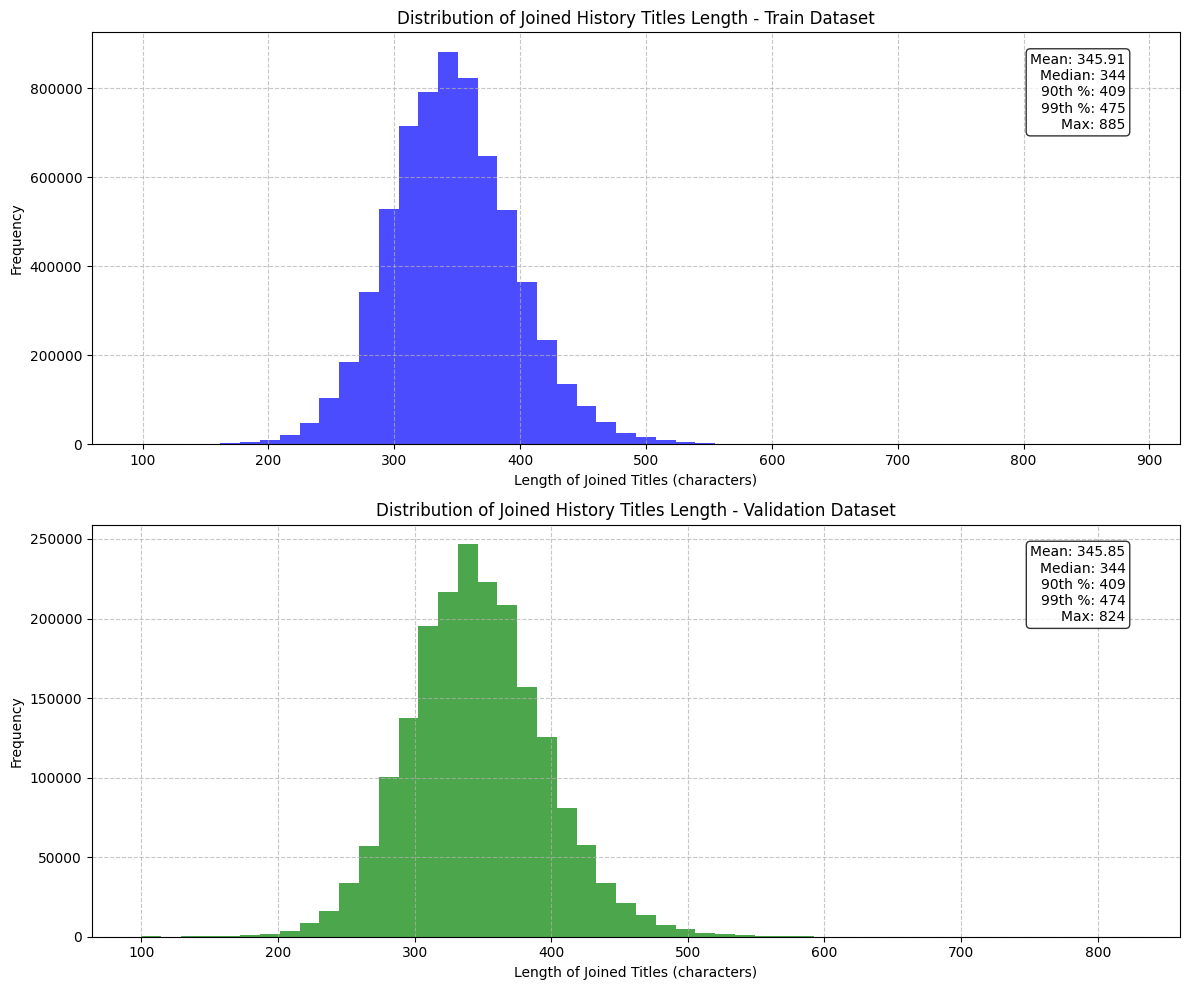


Percentage of samples exceeding character thresholds:
Threshold | Train Dataset | Validation Dataset
--------------------------------------------------
      256 |         97.12% |             97.08%
      512 |          0.24% |              0.24%
     1024 |          0.00% |              0.00%
     2048 |          0.00% |              0.00%
     4096 |          0.00% |              0.00%


In [35]:
# Create a function to join history titles into a single string
def join_history_titles(titles_list):
    """Join a list of history titles into a single string"""
    if not titles_list or len(titles_list) == 0:
        return ""
    return " ".join(titles_list)

# Apply the function to create a new column with joined history titles
df_train_final['History_Titles_Joined'] = df_train_final['History_Title_Sample'].apply(join_history_titles)
df_valid_final['History_Titles_Joined'] = df_valid_final['History_Title_Sample'].apply(join_history_titles)

# Calculate lengths of the joined strings
df_train_final['History_Joined_Length'] = df_train_final['History_Titles_Joined'].apply(len)
df_valid_final['History_Joined_Length'] = df_valid_final['History_Titles_Joined'].apply(len)

# Display statistics for train dataset
print("Train dataset joined history titles length statistics:")
print(df_train_final['History_Joined_Length'].describe())

# Display statistics for validation dataset
print("\nValidation dataset joined history titles length statistics:")
print(df_valid_final['History_Joined_Length'].describe())

# Create histograms to visualize the distribution
import matplotlib.pyplot as plt

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(12, 10))

# Train dataset histogram
axes[0].hist(df_train_final['History_Joined_Length'], bins=50, alpha=0.7, color='blue')
axes[0].set_title('Distribution of Joined History Titles Length - Train Dataset')
axes[0].set_xlabel('Length of Joined Titles (characters)')
axes[0].set_ylabel('Frequency')
axes[0].grid(True, linestyle='--', alpha=0.7)

# Validation dataset histogram
axes[1].hist(df_valid_final['History_Joined_Length'], bins=50, alpha=0.7, color='green')
axes[1].set_title('Distribution of Joined History Titles Length - Validation Dataset')
axes[1].set_xlabel('Length of Joined Titles (characters)')
axes[1].set_ylabel('Frequency')
axes[1].grid(True, linestyle='--', alpha=0.7)

# Calculate and display percentiles
train_percentiles = df_train_final['History_Joined_Length'].quantile([0.5, 0.9, 0.95, 0.99])
valid_percentiles = df_valid_final['History_Joined_Length'].quantile([0.5, 0.9, 0.95, 0.99])

print("\nTrain dataset percentiles:")
print(train_percentiles)
print("\nValidation dataset percentiles:")
print(valid_percentiles)

# Add text with statistics to the plots
train_stats = f'Mean: {df_train_final["History_Joined_Length"].mean():.2f}\n' \
              f'Median: {df_train_final["History_Joined_Length"].median():.0f}\n' \
              f'90th %: {train_percentiles[0.9]:.0f}\n' \
              f'99th %: {train_percentiles[0.99]:.0f}\n' \
              f'Max: {df_train_final["History_Joined_Length"].max():.0f}'

valid_stats = f'Mean: {df_valid_final["History_Joined_Length"].mean():.2f}\n' \
              f'Median: {df_valid_final["History_Joined_Length"].median():.0f}\n' \
              f'90th %: {valid_percentiles[0.9]:.0f}\n' \
              f'99th %: {valid_percentiles[0.99]:.0f}\n' \
              f'Max: {df_valid_final["History_Joined_Length"].max():.0f}'

axes[0].text(0.95, 0.95, train_stats, transform=axes[0].transAxes, 
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

axes[1].text(0.95, 0.95, valid_stats, transform=axes[1].transAxes, 
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

# Calculate percentage of samples with joined history exceeding certain thresholds
thresholds = [256, 512, 1024, 2048, 4096]
print("\nPercentage of samples exceeding character thresholds:")
print("Threshold | Train Dataset | Validation Dataset")
print("-" * 50)
for threshold in thresholds:
    train_pct = (df_train_final['History_Joined_Length'] > threshold).mean() * 100
    valid_pct = (df_valid_final['History_Joined_Length'] > threshold).mean() * 100
    print(f"{threshold:9d} | {train_pct:13.2f}% | {valid_pct:17.2f}%")

In [36]:
# Filter out samples where joined history length exceeds 512 characters
df_train_filtered = df_train_final[df_train_final['History_Joined_Length'] <= 512]
df_valid_filtered = df_valid_final[df_valid_final['History_Joined_Length'] <= 512]

# Reset indices
df_train_filtered = df_train_filtered.reset_index(drop=True)
df_valid_filtered = df_valid_filtered.reset_index(drop=True)

# Calculate percentage of data retained after filtering
train_retention = len(df_train_filtered) / len(df_train_final) * 100
valid_retention = len(df_valid_filtered) / len(df_valid_final) * 100

print(f"Train data - Before filtering: {len(df_train_final)} rows, After filtering: {len(df_train_filtered)} rows")
print(f"Percentage of train data retained: {train_retention:.2f}%")

print(f"\nValid data - Before filtering: {len(df_valid_final)} rows, After filtering: {len(df_valid_filtered)} rows")
print(f"Percentage of valid data retained: {valid_retention:.2f}%")

Train data - Before filtering: 6566391 rows, After filtering: 6550416 rows
Percentage of train data retained: 99.76%

Valid data - Before filtering: 1958979 rows, After filtering: 1954198 rows
Percentage of valid data retained: 99.76%


In [37]:
# Count the number of unique users in train and valid datasets
train_users_count = df_train_filtered['User ID'].nunique()
valid_users_count = df_valid_filtered['User ID'].nunique()

# Calculate overlap between train and valid sets
train_users = set(df_train_filtered['User ID'].unique())
valid_users = set(df_valid_filtered['User ID'].unique())
common_users = train_users.intersection(valid_users)

# Calculate percentage of users that appear in both datasets
percentage_common = (len(common_users) / len(train_users.union(valid_users))) * 100

# Display results
print(f"Number of unique users in train dataset: {train_users_count}")
print(f"Number of unique users in valid dataset: {valid_users_count}")
print(f"Number of users that appear in both datasets: {len(common_users)}")
print(f"Percentage of users that appear in both datasets: {percentage_common:.2f}%")

# Calculate statistics on interactions per user
train_interactions_per_user = df_train_filtered.groupby('User ID').size()
valid_interactions_per_user = df_valid_filtered.groupby('User ID').size()

# Display statistics
print("\nTrain interactions per user:")
print(f"  Mean: {train_interactions_per_user.mean():.2f}")
print(f"  Median: {train_interactions_per_user.median():.2f}")
print(f"  Min: {train_interactions_per_user.min()}")
print(f"  Max: {train_interactions_per_user.max()}")

print("\nValid interactions per user:")
print(f"  Mean: {valid_interactions_per_user.mean():.2f}")
print(f"  Median: {valid_interactions_per_user.median():.2f}")
print(f"  Min: {valid_interactions_per_user.min()}")
print(f"  Max: {valid_interactions_per_user.max()}")

Number of unique users in train dataset: 111780
Number of unique users in valid dataset: 111780
Number of users that appear in both datasets: 111780
Percentage of users that appear in both datasets: 100.00%

Train interactions per user:
  Mean: 58.60
  Median: 60.00
  Min: 17
  Max: 60

Valid interactions per user:
  Mean: 17.48
  Median: 20.00
  Min: 1
  Max: 20


In [39]:
# Count interactions per user in the validation dataset
valid_interaction_counts = df_valid_filtered.groupby('User ID').size()

# Identify users with fewer than 10 interactions
low_interaction_users = valid_interaction_counts[valid_interaction_counts < 10]

# Calculate statistics
total_users = len(valid_interaction_counts)
low_count = len(low_interaction_users)
percentage = (low_count / total_users) * 100

# Display results
print(f"Total unique users in validation dataset: {total_users}")
print(f"Users with fewer than 10 interactions: {low_count} ({percentage:.2f}%)")

# Show distribution of low interaction counts
count_distribution = low_interaction_users.value_counts().sort_index()
print("\nDistribution of interaction counts:")
for count, frequency in count_distribution.items():
    print(f"{count} interactions: {frequency} users")

# Filter both datasets to remove users with low interactions
users_to_keep = valid_interaction_counts[valid_interaction_counts >= 10].index
df_valid_final_filtered = df_valid_filtered[df_valid_filtered['User ID'].isin(users_to_keep)]
df_train_final_filtered = df_train_filtered[df_train_filtered['User ID'].isin(users_to_keep)]

# Reset indices
df_valid_final_filtered = df_valid_final_filtered.reset_index(drop=True)
df_train_final_filtered = df_train_final_filtered.reset_index(drop=True)

# Show the impact of filtering
print(f"\nBefore filtering - Train: {len(df_train_filtered)} rows, Valid: {len(df_valid_filtered)} rows")
print(f"After filtering - Train: {len(df_train_final_filtered)} rows, Valid: {len(df_valid_final_filtered)} rows")

# Calculate percentage of data retained
train_retention = len(df_train_final_filtered) / len(df_train_filtered) * 100
valid_retention = len(df_valid_final_filtered) / len(df_valid_filtered) * 100

print(f"\nPercentage of train data retained: {train_retention:.2f}%")
print(f"Percentage of valid data retained: {valid_retention:.2f}%")

# Count remaining users
remaining_users = df_valid_final_filtered['User ID'].nunique()
print(f"\nRemaining users after filtering: {remaining_users} out of {total_users} ({remaining_users/total_users*100:.2f}%)")

Total unique users in validation dataset: 111780
Users with fewer than 10 interactions: 12287 (10.99%)

Distribution of interaction counts:
1 interactions: 17 users
2 interactions: 2741 users
3 interactions: 305 users
4 interactions: 1647 users
5 interactions: 1823 users
6 interactions: 639 users
7 interactions: 3449 users
8 interactions: 901 users
9 interactions: 765 users

Before filtering - Train: 6550416 rows, Valid: 1954198 rows
After filtering - Train: 5856063 rows, Valid: 1890011 rows

Percentage of train data retained: 89.40%
Percentage of valid data retained: 96.72%

Remaining users after filtering: 99493 out of 111780 (89.01%)


In [41]:
import random

# Set seed for reproducibility
random.seed(42)

# Get list of unique users
unique_users = list(df_train_final_filtered['User ID'].unique())
print(f"Total unique users: {len(unique_users)}")

# Sample 50k users
sample_size = 50000
if len(unique_users) > sample_size:
    sampled_users = random.sample(unique_users, sample_size)
    print(f"Sampled {len(sampled_users)} users")
else:
    sampled_users = unique_users
    print(f"Using all {len(sampled_users)} users as sample size exceeds available users")

# Filter both datasets to keep only sampled users
df_train_sampled_50k = df_train_final_filtered[df_train_final_filtered['User ID'].isin(sampled_users)]
df_valid_sampled_50k = df_valid_final_filtered[df_valid_final_filtered['User ID'].isin(sampled_users)]

# Reset indices
df_train_sampled_50k = df_train_sampled_50k.reset_index(drop=True)
df_valid_sampled_50k = df_valid_sampled_50k.reset_index(drop=True)

# Print statistics
print(f"\nTrain data - Before sampling: {len(df_train_final_filtered)} rows, After sampling: {len(df_train_sampled_50k)} rows")
print(f"Percentage of train data retained: {len(df_train_sampled_50k) / len(df_train_final_filtered) * 100:.2f}%")

print(f"\nValid data - Before sampling: {len(df_valid_final_filtered)} rows, After sampling: {len(df_valid_sampled_50k)} rows")
print(f"Percentage of valid data retained: {len(df_valid_sampled_50k) / len(df_valid_final_filtered) * 100:.2f}%")

# Check label distribution in sampled data
train_positive_ratio = df_train_sampled_50k['Label'].mean() * 100
valid_positive_ratio = df_valid_sampled_50k['Label'].mean() * 100

print(f"\nPositive interaction ratio in train sample: {train_positive_ratio:.2f}%")
print(f"Positive interaction ratio in valid sample: {valid_positive_ratio:.2f}%")


Total unique users: 99493
Sampled 50000 users

Train data - Before sampling: 5856063 rows, After sampling: 2942742 rows
Percentage of train data retained: 50.25%

Valid data - Before sampling: 1890011 rows, After sampling: 949326 rows
Percentage of valid data retained: 50.23%

Positive interaction ratio in train sample: 18.44%
Positive interaction ratio in valid sample: 15.79%


In [43]:
# Drop the specified columns to create a clean version for saving
df_train_final_clean = df_train_sampled_50k.drop(['History_Title_List', 'History_Titles_Joined', 'History_Joined_Length'], axis=1)
df_valid_final_clean = df_valid_sampled_50k.drop(['History_Title_List', 'History_Titles_Joined', 'History_Joined_Length'], axis=1)

In [45]:
# Rename the column from 'History_Title_Sample' to 'History_Interact_Title'
df_train_final_clean = df_train_final_clean.rename(columns={'History_Title_Sample': 'History_Interact_Title'})
df_valid_final_clean = df_valid_final_clean.rename(columns={'History_Title_Sample': 'History_Interact_Title'})

In [47]:
# 保存数据到文件
df_train_final_clean.to_csv('datasets/MIND/train_sampled_50k.tsv', sep='\t', index=False)
df_valid_final_clean.to_csv('datasets/MIND/valid_sampled_50k.tsv', sep='\t', index=False)